# Instructor Effectiveness Modeling

# Step 1: Exploratory Data Analysis (EDA)

This section explores the structure, quality, distributions, and relationships
within the batch-level instructor performance data.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_excel(r"C:\Users\simra\Documents\Downloads\instructor_effectiveness_dataset_2000_rows.xlsx")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [53]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (2000, 12)

Columns:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']

Data types:
batch_id                       object
instructor_id                  object
course_id                      object
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [55]:
#Checking for duplicate records and duplicate batch Ids

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate batch IDs:", df["batch_id"].duplicated().sum())

Duplicate rows: 0
Duplicate batch IDs: 0


In [56]:
# Summary statistics for all numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
completion_rate,2000.0,0.602808,0.159667,0.300000,0.489260,0.603091,0.712797,0.980000
avg_score_improvement,2000.0,27.035844,5.716641,6.159240,23.124673,26.938629,30.885600,40.000000
avg_quiz_score,2000.0,77.956126,10.695618,40.386725,70.897590,78.020567,85.444286,100.000000
dropout_rate,2000.0,0.394883,0.162747,0.020000,0.280035,0.394820,0.511432,0.700000
avg_watch_time,2000.0,0.776515,0.145231,0.287440,0.675076,0.780330,0.894242,1.000000
assignment_submission_rate,2000.0,0.753188,0.148058,0.251111,0.652110,0.756380,0.856458,1.000000
forum_activity_rate,2000.0,0.250300,0.100640,0.000000,0.179845,0.249771,0.319204,0.641111
avg_feedback_score,2000.0,4.207134,0.419209,2.639915,3.918986,4.205989,4.503437,5.000000
feedback_response_rate,2000.0,0.736519,0.149412,0.259935,0.633293,0.737213,0.845876,1.000000


In [57]:
# Number of unique instructors and courses

print("Unique instructors:", df["instructor_id"].nunique())
print("Unique courses:", df["course_id"].nunique())
print("Unique batches:", df["batch_id"].nunique())

Unique instructors: 120
Unique courses: 25
Unique batches: 2000


# 1.1 Distribution of Numerical Features

The distributions of the learner outcome, engagement, and feedback variables
are examined to understand their central tendency, spread, and potential
outliers before feature engineering.

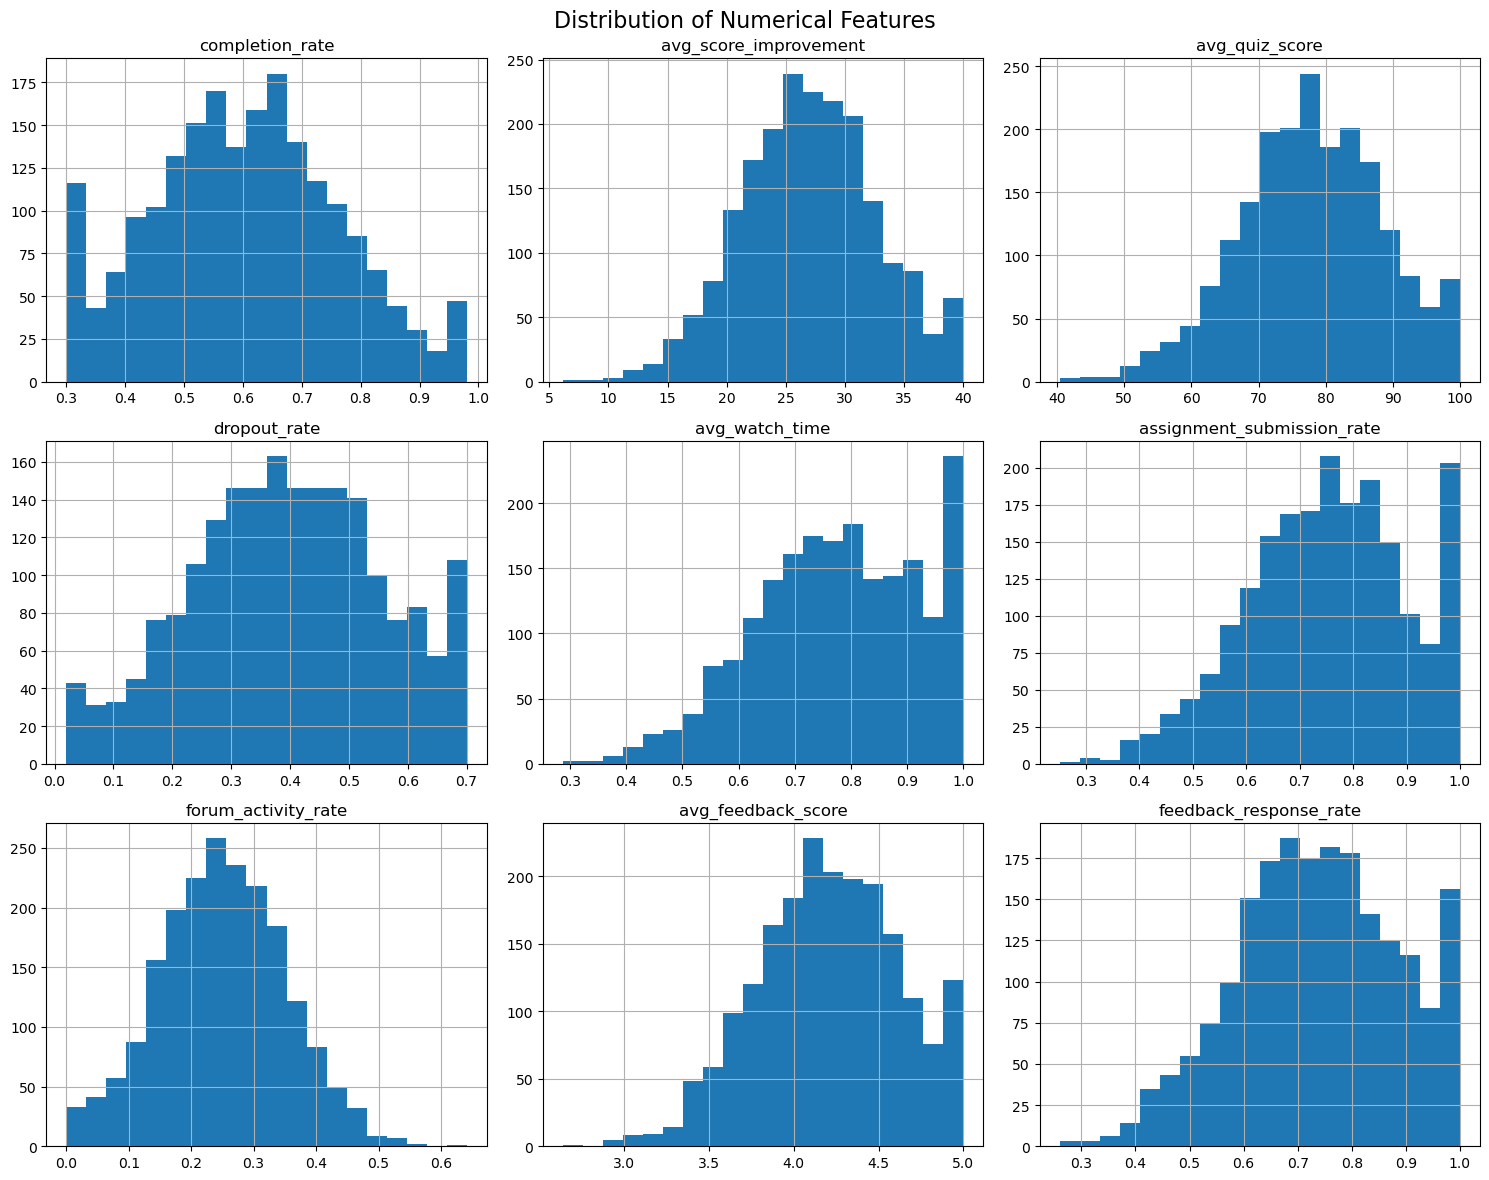

In [58]:
numeric_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64


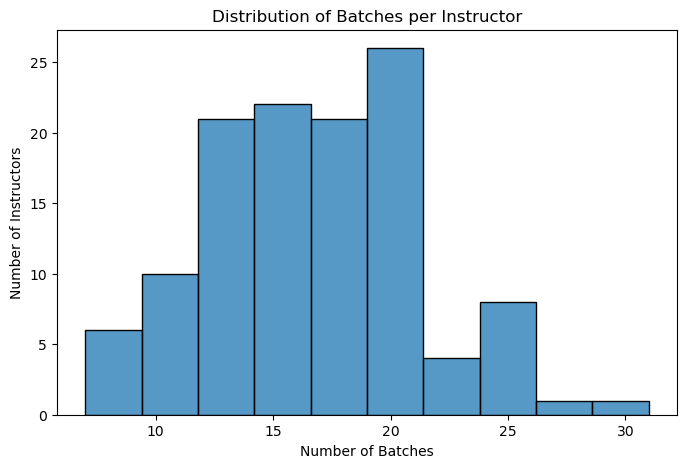

In [59]:
batches_per_instructor = df.groupby("instructor_id").size()

print(batches_per_instructor.describe())

plt.figure(figsize=(8, 5))
sns.histplot(batches_per_instructor, bins=10)

plt.title("Distribution of Batches per Instructor")
plt.xlabel("Number of Batches")
plt.ylabel("Number of Instructors")

plt.show()

# Key Observations

The numerical variables show meaningful variation across course batches, which
provides sufficient variability for subsequent analysis.

Completion rate is centered around approximately 0.60, while dropout rate is
centered around approximately 0.39. Engagement measures such as average watch
time and assignment submission rate are generally relatively high, whereas
forum activity is lower and shows a narrower range.

Average feedback scores are concentrated toward the higher end of the 1–5
scale, indicating generally positive learner feedback. The distributions do
not reveal obvious invalid values based on the expected ranges of the
variables.

The dataset contains 120 instructors, with each instructor teaching between
7 and 31 batches. This variation reinforces the need to aggregate batch-level
observations at the instructor level rather than treating every batch as an
independent instructor observation.

## 1.2 Correlation Analysis

Correlation analysis is used to examine relationships between learner
outcomes, engagement, and feedback variables. This helps identify variables
that may provide overlapping information and provides early insight into
potential drivers of instructor effectiveness.

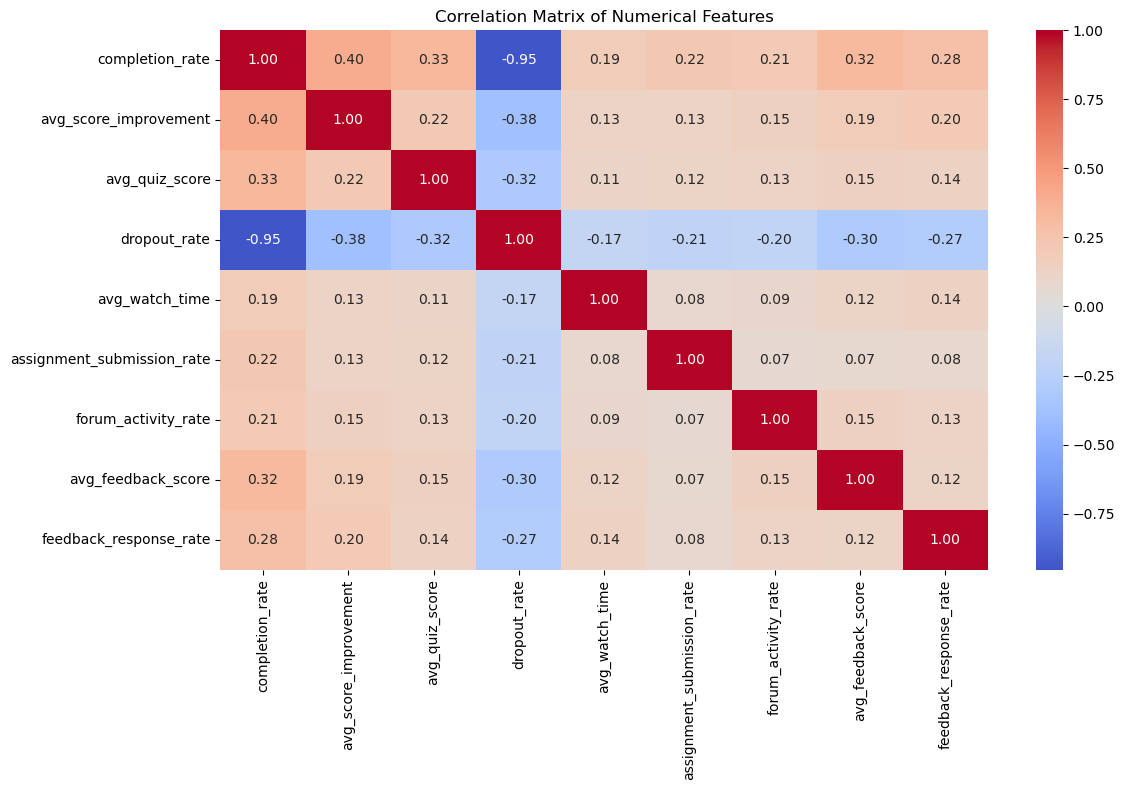

In [60]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [61]:
correlation_matrix.round(2)

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
completion_rate,1.00,0.40,0.33,-0.95,0.19,0.22,0.21,0.32,0.28
avg_score_improvement,0.40,1.00,0.22,-0.38,0.13,0.13,0.15,0.19,0.20
avg_quiz_score,0.33,0.22,1.00,-0.32,0.11,0.12,0.13,0.15,0.14
dropout_rate,-0.95,-0.38,-0.32,1.00,-0.17,-0.21,-0.20,-0.30,-0.27
avg_watch_time,0.19,0.13,0.11,-0.17,1.00,0.08,0.09,0.12,0.14
assignment_submission_rate,0.22,0.13,0.12,-0.21,0.08,1.00,0.07,0.07,0.08
forum_activity_rate,0.21,0.15,0.13,-0.20,0.09,0.07,1.00,0.15,0.13
avg_feedback_score,0.32,0.19,0.15,-0.30,0.12,0.07,0.15,1.00,0.12
feedback_response_rate,0.28,0.20,0.14,-0.27,0.14,0.08,0.13,0.12,1.00


# Outlier Analysis

Boxplots are used to identify unusually high or low observations in the
batch-level metrics. Potential outliers are examined rather than
automatically removed, since unusual batches may represent genuine variation
in course delivery or learner behavior.

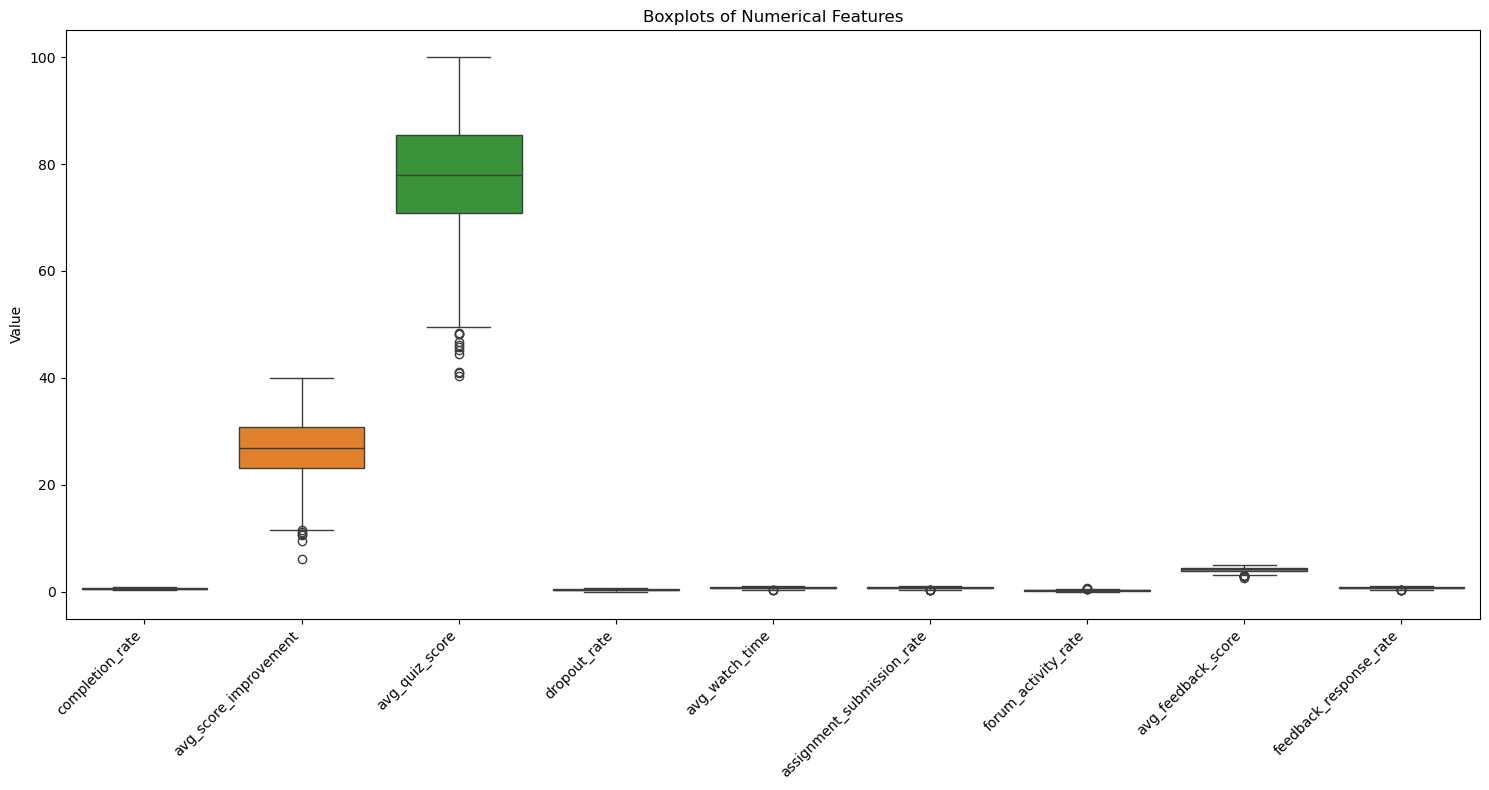

In [62]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45, ha="right")
plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

## EDA Summary

The dataset contains 2,000 unique course batches taught by 120 instructorsacross 25 courses. There are no missing values or duplicate batch records.

The numerical variables show meaningful variation across batches in learner outcomes, engagement, and feedback. Instructors teach multiple batches, with the number of batches varying across instructors, making instructor-level aggregation important for the analysis. The correlation analysis shows a very strong negative relationship between completion rate and dropout rate (r = -0.95). Completion rate also has moderate positive relationships with score improvement, quiz score, feedback score, and feedback response rate. Some potential outliers were observed, but they were not removed because they may represent legitimate differences between course batches.

Overall, the EDA suggests that instructor effectiveness should be evaluatedusing multiple dimensions rather than a single metric, combining learneroutcomes, engagement, and learner feedback.

## Step 2: Define Instructor Effectiveness

Instructor effectiveness is defined as a combination of learner outcomes, learner engagement, and learner feedback. Learner outcomes are given the highest weight because they most directly represent the learning results associated with a batch. Engagement and feedback are included as complementary dimensions.
Since the variables are measured on different scales, they are normalized to a common 0–1 range before calculating the effectiveness score.

In [63]:
from sklearn.preprocessing import MinMaxScaler

# Features where higher values indicate better outcomes
positive_features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

# Normalize positive features
scaler = MinMaxScaler()

df_normalized = df.copy()

df_normalized[positive_features] = scaler.fit_transform(
    df[positive_features]
)

# Normalize dropout separately and reverse it
dropout_scaled = scaler.fit_transform(df[["dropout_rate"]])

df_normalized["dropout_effectiveness"] = 1 - dropout_scaled.ravel()

df_normalized.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,dropout_effectiveness
0,B_1861,I_044,C_01,0.000000,0.238373,0.556249,0.647423,0.683637,0.720811,0.169103,0.477227,0.369235,7.731867e-02
1,B_0354,I_119,C_06,0.525324,0.493839,0.619419,0.425098,0.291198,0.998085,0.437599,1.000000,0.640690,4.042678e-01
2,B_1334,I_050,C_03,0.000000,0.293382,0.657185,0.700000,0.968987,0.742683,0.322898,0.371797,0.569542,-2.220446e-16
3,B_0906,I_024,C_21,0.499274,0.534901,0.988179,0.334657,0.784601,0.391839,0.477913,0.664240,1.000000,5.372689e-01
4,B_1290,I_001,C_08,0.334267,0.736459,0.989825,0.521099,0.884150,0.820915,0.393519,0.756886,0.590184,2.630895e-01


In [64]:
#Learner Outcome Score
df_normalized["outcome_score"] = (
    0.30 * df_normalized["completion_rate"] +
    0.15 * df_normalized["dropout_effectiveness"] +
    0.30 * df_normalized["avg_score_improvement"] +
    0.25 * df_normalized["avg_quiz_score"])

#Engagement Score
df_normalized["engagement_score"] = (
    0.40 * df_normalized["avg_watch_time"] +
    0.35 * df_normalized["assignment_submission_rate"] +
    0.25 * df_normalized["forum_activity_rate"])

#Feedback Score
df_normalized["feedback_score"] = (
    0.70 * df_normalized["avg_feedback_score"] +
    0.30 * df_normalized["feedback_response_rate"])

df_normalized["effectiveness_score"] = (
    0.45 * df_normalized["outcome_score"] +
    0.30 * df_normalized["engagement_score"] +
    0.25 * df_normalized["feedback_score"])

In [65]:
df_normalized["effectiveness_score"].describe()

count    2000.000000
mean        0.591133
std         0.108630
min         0.206031
25%         0.517141
50%         0.593680
75%         0.660749
max         0.926996
Name: effectiveness_score, dtype: float64

In [66]:
df_normalized[
    ["outcome_score", "engagement_score", "feedback_score",
     "effectiveness_score"]
].describe()

,outcome_score,engagement_score,feedback_score,effectiveness_score
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.543524,0.606800,0.658029,0.591133
std,0.155057,0.121825,0.144696,0.108630
min,0.099018,0.167317,0.165117,0.206031
25%,0.437036,0.524104,0.558608,0.517141
50%,0.542460,0.611871,0.660629,0.593680
75%,0.646033,0.693393,0.764813,0.660749
max,0.979357,1.000000,1.000000,0.926996


# Instructor-Level Aggregation

Because each instructor may teach multiple batches, batch-level observations are
aggregated to obtain an instructor-level representation.

Mean aggregation is used for the performance, engagement, and feedback metrics
because the objective is to estimate the typical experience and outcomes
associated with each instructor across their batches.

The number of batches taught by each instructor is also retained as a measure
of the amount of evidence available for the instructor-level estimate.

In [67]:
# Columns to aggregate at instructor level
aggregation_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "outcome_score",
    "engagement_score",
    "feedback_score",
    "effectiveness_score"
]

# Aggregate batch-level data to instructor level
instructor_df = df_normalized.groupby("instructor_id")[aggregation_cols].mean()

# Add number of batches taught by each instructor
batch_counts = df.groupby("instructor_id").size()

instructor_df["number_of_batches"] = batch_counts

instructor_df.head()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,outcome_score,engagement_score,feedback_score,effectiveness_score,number_of_batches
instructor_id,,,,,,,,,,,,,,
I_001,0.358658,0.605253,0.646055,0.470593,0.672327,0.635317,0.375209,0.668547,0.587682,0.501292,0.585094,0.644287,0.562181,25
I_002,0.633639,0.709411,0.693645,0.247194,0.771799,0.698745,0.451731,0.721621,0.708591,0.676210,0.666213,0.717712,0.683586,20
I_003,0.688892,0.703843,0.691192,0.234828,0.745203,0.705706,0.462047,0.766972,0.746147,0.693230,0.660590,0.760724,0.700311,18
I_004,0.232836,0.495047,0.625592,0.547261,0.709681,0.677277,0.352917,0.608662,0.623627,0.408455,0.609149,0.613152,0.519837,17
I_005,0.823158,0.780993,0.762270,0.145733,0.785317,0.835679,0.520220,0.662095,0.708399,0.794078,0.736669,0.675986,0.747332,19


In [68]:
print("Number of instructors:", instructor_df.shape[0])
print("Number of instructor-level features:", instructor_df.shape[1])

Number of instructors: 120
Number of instructor-level features: 14


In [69]:
instructor_df["effectiveness_score"].describe()

count    120.000000
mean       0.590389
std        0.092316
min        0.358876
25%        0.529563
50%        0.589399
75%        0.644043
max        0.830798
Name: effectiveness_score, dtype: float64

In [70]:
instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low", "Medium", "High"])
instructor_df["effectiveness_tier"].value_counts().sort_index()
instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(
    ["min", "max", "mean"])

C:\Users\simra\AppData\Local\Temp\ipykernel_12260\643239482.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(


,min,max,mean
effectiveness_tier,,,
Low,0.358876,0.553754,0.492314
Medium,0.557643,0.624244,0.589200
High,0.624330,0.830798,0.689652


In [71]:
print(instructor_df.shape)
instructor_df["effectiveness_score"].describe()
instructor_df["effectiveness_tier"].value_counts().sort_index()
instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(
    ["min", "max", "mean"])

(120, 15)


C:\Users\simra\AppData\Local\Temp\ipykernel_12260\3070243471.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  instructor_df.groupby("effectiveness_tier")["effectiveness_score"].agg(


,min,max,mean
effectiveness_tier,,,
Low,0.358876,0.553754,0.492314
Medium,0.557643,0.624244,0.589200
High,0.624330,0.830798,0.689652


In [72]:
instructor_df["effectiveness_tier"].value_counts().sort_index()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

### Effectiveness Tier Definition

The continuous Instructor Effectiveness Score is converted into three tiers:
Low, Medium, and High.

Because the dataset does not provide predefined business thresholds for
effectiveness, quantile-based thresholds are used. This divides instructors
into three groups based on their relative effectiveness within the available
sample.

This approach avoids imposing arbitrary absolute cutoffs and also provides
sufficient observations in each tier for classification.

In [73]:
feature_cols = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate",
    "number_of_batches"]


In [74]:
target = "effectiveness_tier"

In [75]:
print("Tier distribution:")
print(instructor_df["effectiveness_tier"].value_counts().sort_index())
print("\nScore range by tier:")
print(
    instructor_df.groupby("effectiveness_tier", observed=True)["effectiveness_score"]
    .agg(["min", "max", "mean"]))

Tier distribution:
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

Score range by tier:
                         min       max      mean
effectiveness_tier                              
Low                 0.358876  0.553754  0.492314
Medium              0.557643  0.624244  0.589200
High                0.624330  0.830798  0.689652


# Step 3: Machine Learning

The objective is to predict the instructor effectiveness tier using
instructor-level performance, engagement, feedback, and batch-volume features.

The effectiveness score and its component scores are excluded from the model
features because they were directly used to construct the target tier. Including
them would introduce target leakage and make the model evaluation unreliable.

In [76]:
X = instructor_df[feature_cols]
y = instructor_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()
print(y.value_counts().sort_index())

Feature matrix shape: (120, 10)
Target shape: (120,)
effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining tier distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting tier distribution:")
print(y_test.value_counts().sort_index())

Training set: (96, 10)
Testing set: (24, 10)

Training tier distribution:
effectiveness_tier
Low       32
Medium    32
High      32
Name: count, dtype: int64

Testing tier distribution:
effectiveness_tier
Low       8
Medium    8
High      8
Name: count, dtype: int64


## Step 4: Model Training

A Random Forest classifier is selected because it can capture nonlinear relationships between instructor-level features and effectiveness tiers without requiring feature scaling.

Random Forest also provides feature importance estimates, which can be used to interpret which variables contribute most to the model's predictions.

In [78]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)
print("Actual:")
print(y_test.values)

Predictions:
['Medium' 'Medium' 'Medium' 'Low' 'High' 'Medium' 'High' 'Medium' 'High'
 'Low' 'Low' 'Low' 'High' 'Medium' 'Low' 'Medium' 'High' 'High' 'Low'
 'Medium' 'Low' 'High' 'High' 'Low']
Actual:
['Medium', 'Low', 'Medium', 'Low', 'High', ..., 'Medium', 'Low', 'High', 'High', 'Low']
Length: 24
Categories (3, object): ['Low' < 'Medium' < 'High']


In [80]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"])

print(cm)

Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       0.88      0.88      0.88         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24

[[7 1 0]
 [1 7 0]
 [0 0 8]]


### Model Evaluation

The Random Forest classifier achieved an accuracy of 91.67% on the test set.

The High effectiveness tier was classified perfectly, with both precision and
recall of 1.00. The Low and Medium tiers each achieved precision, recall, and
F1-scores of approximately 0.88.

The confusion matrix shows that 22 out of 24 test-set instructors were
classified correctly. The only errors occurred between the Low and Medium
tiers, while all High-tier instructors were correctly identified.

Because the test set contains only 24 instructors, the evaluation results
should be interpreted cautiously. Nevertheless, the balanced class
distribution and strong F1-scores indicate that the model is able to
distinguish the effectiveness tiers reasonably well.

In [81]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance

completion_rate               0.267150
dropout_rate                  0.218799
feedback_response_rate        0.119019
avg_score_improvement         0.117119
avg_quiz_score                0.092138
avg_feedback_score            0.081075
avg_watch_time                0.039257
forum_activity_rate           0.031264
assignment_submission_rate    0.024208
number_of_batches             0.009971
dtype: float64

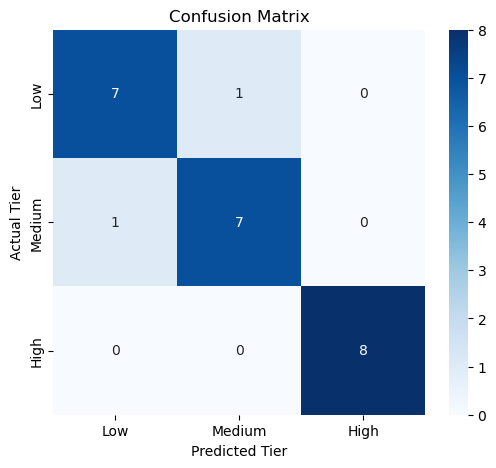

In [82]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")

plt.show()

## Model Interpretation

The Random Forest feature importance indicates that completion rate and dropout
rate are the two most influential predictors of instructor effectiveness tier.
This is consistent with the EDA, where these variables showed a very strong
negative correlation (r = -0.95).

Feedback response rate and average score improvement are the next most
important features, followed by average quiz score and average feedback score.
Engagement measures such as watch time, forum activity, and assignment
submission have comparatively lower importance.

The number of batches taught has very low feature importance, suggesting that
the quantity of batches alone does not strongly distinguish effectiveness
tiers in this dataset.

These results should not be interpreted as causal effects. Since the
effectiveness tier was constructed using the same underlying performance,
engagement, and feedback variables, the model is primarily learning to
reproduce the scoring framework rather than discovering independent causal
drivers of instructor effectiveness.

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, logistic_pred))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

Logistic Regression Accuracy: 0.9583333333333334

Classification Report:
              precision    recall  f1-score   support

        High       0.89      1.00      0.94         8
         Low       1.00      1.00      1.00         8
      Medium       1.00      0.88      0.93         8

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24



## Model Comparison and Cross-Validation

Two classical classification models were considered: Random Forest and
Logistic Regression.

Random Forest can capture nonlinear relationships and provides feature
importance estimates, while Logistic Regression provides a simpler and more
interpretable linear decision boundary.

Because the instructor-level dataset contains only 120 observations, a single
train-test split may produce an unstable performance estimate. Therefore,
5-fold stratified cross-validation is also used to compare the models more
robustly.

In [84]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

# Random Forest cross-validation
rf_cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1_macro")

# Logistic Regression cross-validation
lr_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="f1_macro")

print("Random Forest CV F1 scores:", rf_cv_scores)
print("Random Forest Mean F1:", rf_cv_scores.mean())

print("\nLogistic Regression CV F1 scores:", lr_cv_scores)
print("Logistic Regression Mean F1:", lr_cv_scores.mean())

Random Forest CV F1 scores: [0.87728758 0.95816993 0.91650327 0.8745098  0.91666667]
Random Forest Mean F1: 0.9086274509803921

Logistic Regression CV F1 scores: [0.83333333 0.95816993 0.91650327 0.86643204 0.91650327]
Logistic Regression Mean F1: 0.89818836936484


In [85]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, logistic_pred)],
    "Test Macro F1": [
        0.92,
        0.96],
    "CV Mean Macro F1": [
        rf_cv_scores.mean(),
        lr_cv_scores.mean()]})

comparison

,Model,Test Accuracy,Test Macro F1,CV Mean Macro F1
0,Random Forest,0.916667,0.92,0.908627
1,Logistic Regression,0.958333,0.96,0.898188


# Model Comparison

Two classical classification models were evaluated: Random Forest and
Logistic Regression.

Logistic Regression achieved a higher accuracy and Macro F1-score on the
single held-out test set. However, 5-fold stratified cross-validation produced
a higher mean Macro F1-score for Random Forest (0.909) compared with Logistic
Regression (0.898).

Because the instructor-level dataset contains only 120 observations, relying
on a single 24-observation test set may produce a relatively unstable
performance estimate. Therefore, the cross-validation result is given greater
weight when selecting the final model.

Based on this comparison, Random Forest is selected as the final model because
it achieved the stronger cross-validated Macro F1-score. It also provides
feature importance estimates that support interpretation of the model.

In [86]:
final_model = model

final_predictions = final_model.predict(X_test)

print("Final Model: Random Forest")
print("Test Accuracy:", accuracy_score(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Final Model: Random Forest
Test Accuracy: 0.9166666666666666

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         8
         Low       0.88      0.88      0.88         8
      Medium       0.88      0.88      0.88         8

    accuracy                           0.92        24
   macro avg       0.92      0.92      0.92        24
weighted avg       0.92      0.92      0.92        24



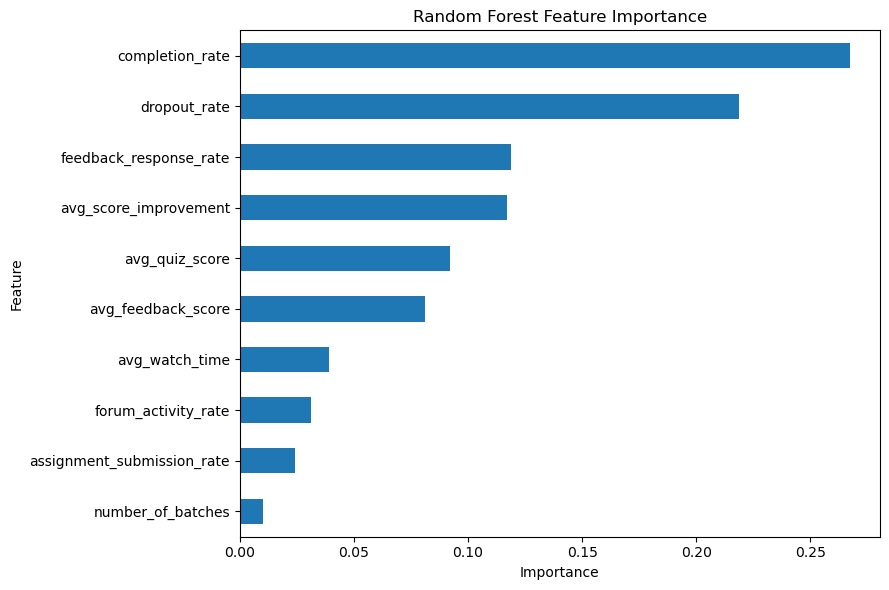

In [87]:
final_importance = pd.Series(
    final_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
final_importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Analysis Questions

## 1. Which features most influenced instructor effectiveness, and why?
The most important features were completion rate and dropout rate, with feature importance values of 0.267 and 0.218. This makes sense because an instructor who is able to keep learners engaged and help them complete the course would generally be considered more effective. Feedback response rate and average score improvement were also important, showing that learner participation in feedback and actual learning progress contribute to effectiveness. However, these results should not be treated as causal because these same variables were used to create the effectiveness score.

## 2. Which variables could be misleading or confounded?
Completion rate and dropout rate could be somewhat misleading because they have a very strong negative correlation of -0.95 and therefore provide similar information from opposite directions. Feedback scores could also be affected by response bias because not every learner submits feedback. Other factors such as course difficulty, learner background, prior knowledge, and batch composition could also affect the results without being directly related to the instructor.

## 3. How could this model fail in real-world usage?
The model could perform poorly when used on new instructors, courses, or learner groups that are different from the data used to train it. For example, a difficult course or a batch with learners who have weaker prior knowledge could result in lower completion or quiz scores even if the instructor is effective. The model could also become less reliable over time if learner behavior or course structure changes. Another limitation is that our dataset contains only 120 instructors, so the results may not generalize to a much larger population.
## 4. What additional data would you want to improve this analysis?
I would want additional information such as course difficulty, batch size, instructor experience, learner attendance, pre-course assessment scores, learner background, instructor-learner interaction, and historical performance. It would also be useful to have more detailed feedback about teaching quality rather than only an average feedback score. These additional variables would help separate the effect of the instructor from the effect of the learners and the course itself.
## 5. Should this model be used for instructor performance evaluation? Why or why not?
I would not use this model as the only method for evaluating an instructor. It can be useful for identifying patterns and helping the company find instructors or batches that may need further attention. However, the model does not capture every factor that affects teaching effectiveness, and the effectiveness tiers are based on the available dataset rather than an independently validated standard. Therefore, important decisions about an instructor should also include human review and other relevant information.

## Conclusion

This analysis evaluated instructor effectiveness using batch-level learner
performance, engagement, and feedback data. The data was aggregated from 2,000
batch records to 120 instructor-level records, after which instructors were
divided into Low, Medium, and High effectiveness tiers.

The Random Forest model achieved 91.67% accuracy on the test set and a
5-fold cross-validation Macro F1-score of approximately 0.91. Completion rate
and dropout rate were the most important features in the model, followed by
feedback response rate and average score improvement.

The results suggest that learner completion, retention, feedback interaction,
and learning progress are useful indicators of instructor effectiveness.
However, the model should be treated as a decision-support tool rather than a
standalone performance evaluation system because the dataset is relatively
small and several learner, course, and instructor-level factors are not
available.

Overall, the analysis provides a useful framework for identifying patterns in
instructor effectiveness while highlighting the need for additional data and
human judgment before making high-stakes decisions.